In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
# escolher o número de componentes
# número de componentes é hiperparâmetro
df_normal = pd.read_parquet("../df_normal.parquet")
X = df_normal.copy()
X_num = X.select_dtypes(include=["int64", "float64"])
pca = PCA()
pca.fit(X_num)

# calcular a variância acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

Gráfico da Variância Acumlada

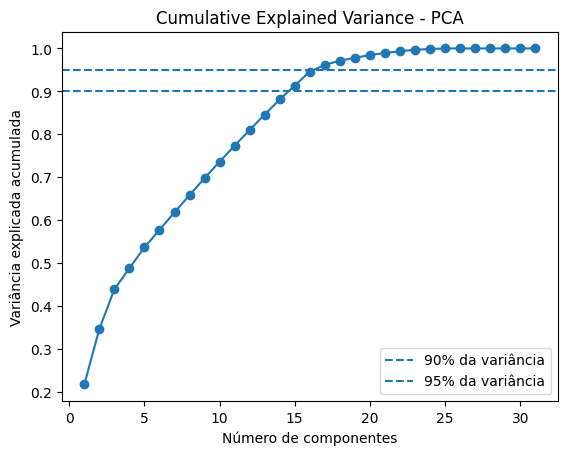

In [3]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.axhline(y=0.90, linestyle='--', label='90% da variância')
plt.axhline(y=0.95, linestyle='--', label='95% da variância')
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("Cumulative Explained Variance - PCA")
plt.legend()
plt.show()

Aplicar Modelo

In [ ]:
pca = PCA(n_components=15)
X_pca = pca.fit_transform(X_num)
df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(15)]
)

Análise

Explained variance ratio:
[0.21690002 0.12937801]

Total explained variance:
0.34627803142673524


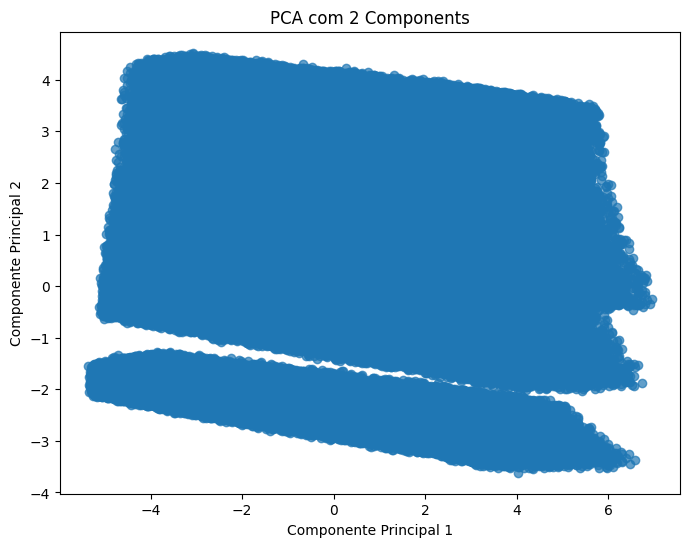

In [4]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA 
df = pd.read_parquet("../df_normal.parquet")
X = df.select_dtypes(include=["number"])

# PCA com 2 componentes
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# DataFrame com os componentes principais
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

# Variância explicada
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

# Visualização
plt.figure(figsize=(8,6))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    alpha=0.7
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("PCA com 2 Components")

plt.show()

In [5]:
import numpy as np
print("\nRazão da variância explicada por componente:\n")
print(pca.explained_variance_ratio_)
print("\nVariância Explicada Acumulada:\n")
print(np.cumsum(pca.explained_variance_ratio_))
print("\nNúmero de Componentes:\n")
print(pca.n_components)
print("\nValores Singulares:\n")
print(pca.singular_values_)
print("\nComponente Principais (direções):\n")
print(pca.components_)


Razão da variância explicada por componente:

[0.21690002 0.12937801]

Variância Explicada Acumulada:

[0.21690002 0.34627803]

Número de Componentes:

2

Valores Singulares:

[2006.05445933 1549.32726119]

Componente Principais (direções):

[[ 3.70832064e-01  1.31831465e-04 -4.13101773e-03  3.33842410e-01
   6.33142697e-02  2.59218564e-02  3.58178478e-02 -1.02525127e-02
   2.11699076e-02 -6.09765345e-03 -2.65477188e-02  1.38246342e-03
   1.57794438e-03 -5.61303107e-03  3.75609551e-03  1.24027677e-03
  -3.70642629e-03 -1.77912905e-03  3.63156641e-03  1.60027385e-01
   5.81222259e-02  3.49654629e-01  3.58185285e-01  3.58707309e-01
   3.69210677e-01  5.81222259e-02  3.49654629e-01  7.86078494e-02
   7.46832384e-02  5.81222259e-02  2.41607741e-01]
 [-4.31199838e-02  2.92466131e-03  1.75194354e-01  7.22751616e-02
   4.57450620e-01 -9.06790156e-03 -5.65643354e-03  1.48617253e-02
  -5.66803598e-03 -3.35964799e-04 -5.98742605e-03  2.26440892e-03
  -9.43903379e-03 -3.16028505e-03  2.48809597e

In [7]:
type(pca)

sklearn.decomposition._pca.PCA

In [8]:
print(f"Número de clusters: {pca.n_clusters}")
print(f"Inércia (soma das distâncias intra-cluster): {pca.inertia_:.2f}")

AttributeError: 'PCA' object has no attribute 'n_clusters'

In [10]:
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pandas as pd
import numpy as np

# =========================
# PCA
# =========================

pca = PCA(n_components=15)

X_pca = pca.fit_transform(X_num)

df_pca = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(15)]
)

# =========================
# MÉTRICAS PCA
# =========================

print("=" * 50)
print("MÉTRICAS DO PCA")
print("=" * 50)

# Variância explicada por componente
print("\n[1] EXPLAINED VARIANCE RATIO")
print(pca.explained_variance_ratio_)

# Variância acumulada
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print("\n[2] VARIÂNCIA ACUMULADA")
print(cumulative_variance)

# Variância total explicada
total_variance = np.sum(
    pca.explained_variance_ratio_
)

print("\n[3] VARIÂNCIA TOTAL EXPLICADA")
print(total_variance)

# Número de componentes
print("\n[4] NÚMERO DE COMPONENTES")
print(pca.n_components_)

# =========================
# INTERPRETAÇÃO AUTOMÁTICA
# =========================

print("\n" + "=" * 50)
print("INTERPRETAÇÃO")
print("=" * 50)

if total_variance > 0.90:
    print("\nPCA: Excelente retenção de informação")

elif total_variance > 0.75:
    print("\nPCA: Boa retenção de informação")

elif total_variance > 0.60:
    print("\nPCA: Retenção razoável")

else:
    print("\nPCA: Possível perda significativa de informação")

# =========================
# COMPONENTES MAIS IMPORTANTES
# =========================

print("\n" + "=" * 50)
print("IMPORTÂNCIA DAS COMPONENTES")
print("=" * 50)

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

# =========================
# ATRIBUTOS DO MODELO PCA
# =========================

print("\n" + "=" * 50)
print("ATRIBUTOS DO PCA")
print("=" * 50)

for attr in dir(pca):
    if attr.endswith("_"):
        print(attr)

MÉTRICAS DO PCA

[1] EXPLAINED VARIANCE RATIO
[0.21690002 0.12937801 0.09223913 0.04926346 0.04840583 0.04100065
 0.04075093 0.04019317 0.03965389 0.03828762 0.0373185  0.03646747
 0.03603167 0.03518053 0.03249752]

[2] VARIÂNCIA ACUMULADA
[0.21690002 0.34627803 0.43851716 0.48778062 0.53618645 0.57718709
 0.61793803 0.65813119 0.69778508 0.7360727  0.7733912  0.80985868
 0.84589035 0.88107088 0.9135684 ]

[3] VARIÂNCIA TOTAL EXPLICADA
0.9135683952937618

[4] NÚMERO DE COMPONENTES
15

INTERPRETAÇÃO

PCA: Excelente retenção de informação

IMPORTÂNCIA DAS COMPONENTES
PC1: 0.2169
PC2: 0.1294
PC3: 0.0922
PC4: 0.0493
PC5: 0.0484
PC6: 0.0410
PC7: 0.0408
PC8: 0.0402
PC9: 0.0397
PC10: 0.0383
PC11: 0.0373
PC12: 0.0365
PC13: 0.0360
PC14: 0.0352
PC15: 0.0325

ATRIBUTOS DO PCA
__abstractmethods__
__annotations__
__class__
__delattr__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__le__
__lt__
__module__
__

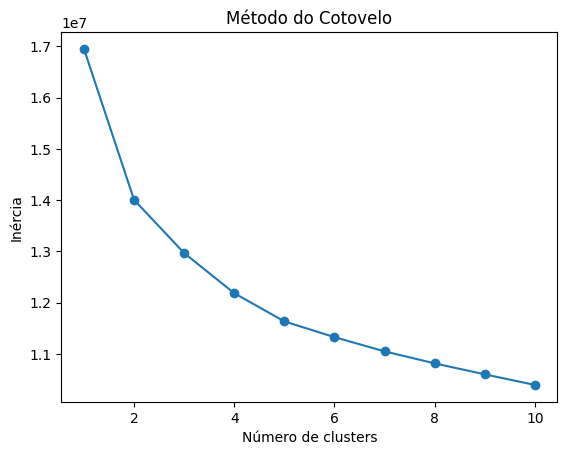

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Usar apenas as componentes PCA, sem a coluna cluster caso já exista
X_cluster = df_pca
# Lista para guardar a inércia
inertia = []
k_range = range(1, 11) # valores para cluster

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Gráfico do cotovelo
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_pca["cluster"] = kmeans.fit_predict(X_cluster)

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# labels clusters
labels = df_pca["cluster"]

silhouette = silhouette_score(X_cluster, labels)
davies = davies_bouldin_score(X_cluster, labels)
calinski = calinski_harabasz_score(X_cluster, labels)


#inertia = kmeans.inertia_

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Score: {calinski:.4f}")
#print(f"Inércia: {inertia:.4f}")